In [1]:
import pandas as pd

monthly = pd.read_csv('pakistan_air_quality_monthly_2015_2025.csv')
annual = pd.read_csv('pakistan_air_quality_annual_summary.csv')
cities = pd.read_csv('pakistan_cities_metadata.csv')

print("Monthly:", monthly.shape)
print("Annual:", annual.shape)
print("Cities:", cities.shape)

Monthly: (1320, 23)
Annual: (110, 17)
Cities: (10, 12)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Merging Datasets

In [3]:
cities_subset = cities[['city', 'is_industrial_hub', 'is_coastal', 'is_capital']]

df = monthly.merge(cities_subset, on='city', how='left')

print(df.shape)
df.head()

(1320, 26)


,year,month,month_name,city,province,region,latitude,longitude,population_millions,pm25_ugm3,...,is_monsoon_season,season,covid_lockdown_period,data_source,data_quality,pakistan_national_avg_pm25,pakistan_global_rank,is_industrial_hub,is_coastal,is_capital
0,2015,1,January,Faisalabad,Punjab,Central Punjab,31.4187,73.0791,3.8,266.3,...,0,Winter (Smog Season),0,IQAir World Air Quality Report 2018-2025 / IQA...,Estimated (pre-monitoring era),NaN,NaN,1,0,0
1,2015,2,February,Faisalabad,Punjab,Central Punjab,31.4187,73.0791,3.8,237.7,...,0,Winter (Smog Season),0,IQAir World Air Quality Report 2018-2025 / IQA...,Estimated (pre-monitoring era),NaN,NaN,1,0,0
2,2015,3,March,Faisalabad,Punjab,Central Punjab,31.4187,73.0791,3.8,145.0,...,0,Spring,0,IQAir World Air Quality Report 2018-2025 / IQA...,Estimated (pre-monitoring era),NaN,NaN,1,0,0
3,2015,4,April,Faisalabad,Punjab,Central Punjab,31.4187,73.0791,3.8,74.7,...,0,Spring,0,IQAir World Air Quality Report 2018-2025 / IQA...,Estimated (pre-monitoring era),NaN,NaN,1,0,0
4,2015,5,May,Faisalabad,Punjab,Central Punjab,31.4187,73.0791,3.8,59.6,...,0,Summer/Monsoon,0,IQAir World Air Quality Report 2018-2025 / IQA...,Estimated (pre-monitoring era),NaN,NaN,1,0,0


In [4]:

df.info()

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1320 entries, 0 to 1319
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   year                        1320 non-null   int64  
 1   month                       1320 non-null   int64  
 2   month_name                  1320 non-null   object 
 3   city                        1320 non-null   object 
 4   province                    1320 non-null   object 
 5   region                      1320 non-null   object 
 6   latitude                    1320 non-null   float64
 7   longitude                   1320 non-null   float64
 8   population_millions         1320 non-null   float64
 9   pm25_ugm3                   1320 non-null   float64
 10  aqi_us                      1320 non-null   int64  
 11  aqi_category                1320 non-null   object 
 12  annual_pm25_avg_ugm3        1320 non-null   float64
 13  who_guideline_ratio         1320 

In [5]:
df.describe()

,year,month,latitude,longitude,population_millions,pm25_ugm3,aqi_us,annual_pm25_avg_ugm3,who_guideline_ratio,is_smog_season,is_crop_burning_season,is_monsoon_season,covid_lockdown_period,pakistan_national_avg_pm25,pakistan_global_rank,is_industrial_hub,is_coastal,is_capital
count,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,960.000000,960.000000,1320.000000,1320.000000,1320.000000
mean,2020.000000,6.500000,30.706130,71.307800,4.790000,73.991288,143.169697,73.973636,14.797955,0.416667,0.083333,0.225000,0.030303,70.535000,2.375000,0.400000,0.100000,0.100000
std,3.163476,3.453361,3.074692,2.702904,5.192044,53.462290,53.090964,30.867629,10.693332,0.493193,0.276490,0.417741,0.171485,5.897765,0.696333,0.490084,0.300114,0.300114
min,2015.000000,1.000000,24.860700,66.975000,1.100000,11.700000,49.000000,30.500000,2.300000,0.000000,0.000000,0.000000,0.000000,59.000000,1.000000,0.000000,0.000000,0.000000
25%,2017.000000,3.750000,30.179800,68.357800,2.000000,34.300000,97.750000,48.100000,6.875000,0.000000,0.000000,0.000000,0.000000,67.752500,2.000000,0.000000,0.000000,0.000000
50%,2020.000000,6.500000,31.469550,72.286400,2.300000,58.000000,152.000000,60.700000,11.600000,0.000000,0.000000,0.000000,0.000000,71.500000,2.500000,0.000000,0.000000,0.000000
75%,2023.000000,9.250000,33.600700,73.079100,3.800000,92.700000,170.000000,105.000000,18.500000,1.000000,0.000000,0.000000,0.000000,73.842500,3.000000,1.000000,0.000000,0.000000
max,2025.000000,12.000000,34.015100,74.358700,16.100000,266.300000,317.000000,145.000000,53.300000,1.000000,1.000000,1.000000,1.000000,80.100000,3.000000,1.000000,1.000000,1.000000


In [6]:
df['aqi_category'].value_counts()

,count
aqi_category,
Unhealthy,513
Moderate,343
Unhealthy for Sensitive Groups,290
Very Unhealthy,170
Hazardous,3
Good,1


In [7]:
df.groupby('city')['aqi_us'].mean().sort_values(ascending=False)

,aqi_us
city,
Faisalabad,190.090909
Gujranwala,181.727273
Multan,174.250000
Lahore,170.818182
Peshawar,135.954545
Quetta,128.015152
Hyderabad,118.856061
Rawalpindi,117.696970
Karachi,109.022727


In [8]:
df.groupby('season')['aqi_us'].mean().sort_values(ascending=False)

,aqi_us
season,
Winter (Smog Season),196.875758
Post-Monsoon,159.078788
Spring,128.772727
Summer/Monsoon,98.156818


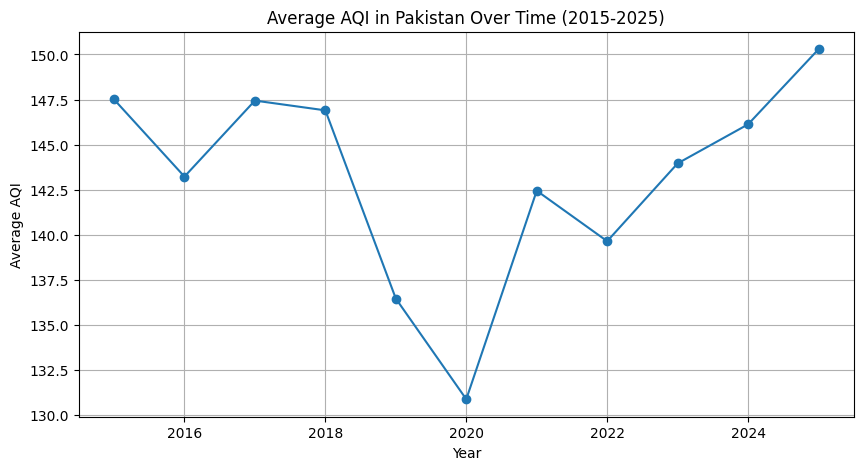

In [9]:
import matplotlib.pyplot as plt

yearly_trend = df.groupby('year')['aqi_us'].mean()
plt.figure(figsize=(10,5))
plt.plot(yearly_trend.index, yearly_trend.values, marker='o')
plt.title('Average AQI in Pakistan Over Time (2015-2025)')
plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.grid(True)
plt.show()

In [10]:
# Drop columns that are mostly empty or not useful for modeling
df_model = df.drop(columns=['pakistan_national_avg_pm25', 'pakistan_global_rank',
                              'annual_pm25_avg_ugm3', 'data_source', 'data_quality',
                              'covid_lockdown_period'])

# Fill remaining missing values (if any) - using median for numeric columns
df_model['who_guideline_ratio'] = df_model['who_guideline_ratio'].fillna(df_model['who_guideline_ratio'].median())

# Encode categorical columns (convert text to numbers models can use)
from sklearn.preprocessing import LabelEncoder

le_city = LabelEncoder()
le_season = LabelEncoder()
le_province = LabelEncoder()

df_model['city_encoded'] = le_city.fit_transform(df_model['city'])
df_model['season_encoded'] = le_season.fit_transform(df_model['season'])
df_model['province_encoded'] = le_province.fit_transform(df_model['province'])

df_model.head()

,year,month,month_name,city,province,region,latitude,longitude,population_millions,pm25_ugm3,...,is_smog_season,is_crop_burning_season,is_monsoon_season,season,is_industrial_hub,is_coastal,is_capital,city_encoded,season_encoded,province_encoded
0,2015,1,January,Faisalabad,Punjab,Central Punjab,31.4187,73.0791,3.8,266.3,...,1,0,0,Winter (Smog Season),1,0,0,0,3,3
1,2015,2,February,Faisalabad,Punjab,Central Punjab,31.4187,73.0791,3.8,237.7,...,1,0,0,Winter (Smog Season),1,0,0,0,3,3
2,2015,3,March,Faisalabad,Punjab,Central Punjab,31.4187,73.0791,3.8,145.0,...,0,0,0,Spring,1,0,0,0,1,3
3,2015,4,April,Faisalabad,Punjab,Central Punjab,31.4187,73.0791,3.8,74.7,...,0,0,0,Spring,1,0,0,0,1,3
4,2015,5,May,Faisalabad,Punjab,Central Punjab,31.4187,73.0791,3.8,59.6,...,0,0,0,Summer/Monsoon,1,0,0,0,2,3


In [11]:
from sklearn.model_selection import train_test_split

# Features (inputs) - the columns the model learns from
features = ['month', 'city_encoded', 'season_encoded', 'province_encoded',
            'is_smog_season', 'is_crop_burning_season', 'is_monsoon_season',
            'is_industrial_hub', 'is_coastal', 'is_capital', 'population_millions']

X = df_model[features]

# Target 1: regression - predict exact AQI number
y_reg = df_model['aqi_us']

# Target 2: classification - predict category
y_clf = df_model['aqi_category']

# Split into train (80%) and test (20%) sets
X_train, X_test, y_reg_train, y_reg_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _, y_clf_train, y_clf_test = train_test_split(X, y_clf, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1056, 11)
Test size: (264, 11)


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, classification_report

# --- Regression baseline ---
lr = LinearRegression()
lr.fit(X_train, y_reg_train)
y_reg_pred = lr.predict(X_test)

print("=== Linear Regression (predicting AQI number) ===")
print("MAE:", mean_absolute_error(y_reg_test, y_reg_pred))
print("R2 Score:", r2_score(y_reg_test, y_reg_pred))

# --- Classification baseline ---
log_clf = LogisticRegression(max_iter=1000)
log_clf.fit(X_train, y_clf_train)
y_clf_pred = log_clf.predict(X_test)

print("\n=== Logistic Regression (predicting AQI category) ===")
print("Accuracy:", accuracy_score(y_clf_test, y_clf_pred))
print(classification_report(y_clf_test, y_clf_pred))

=== Linear Regression (predicting AQI number) ===
MAE: 20.77687873146135
R2 Score: 0.7366102949479785

=== Logistic Regression (predicting AQI category) ===
Accuracy: 0.7348484848484849
                                precision    recall  f1-score   support

                      Moderate       0.78      0.90      0.83        69
                     Unhealthy       0.75      0.79      0.77       101
Unhealthy for Sensitive Groups       0.65      0.50      0.56        66
                Very Unhealthy       0.70      0.68      0.69        28

                      accuracy                           0.73       264
                     macro avg       0.72      0.72      0.72       264
                  weighted avg       0.73      0.73      0.73       264



In [13]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# --- Regression: Random Forest ---
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_reg_train)
y_rf_pred = rf_reg.predict(X_test)

print("=== Random Forest Regressor ===")
print("MAE:", mean_absolute_error(y_reg_test, y_rf_pred))
print("R2 Score:", r2_score(y_reg_test, y_rf_pred))

# --- Classification: Random Forest ---
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_clf_train)
y_rf_clf_pred = rf_clf.predict(X_test)

print("\n=== Random Forest Classifier ===")
print("Accuracy:", accuracy_score(y_clf_test, y_rf_clf_pred))
print(classification_report(y_clf_test, y_rf_clf_pred))

=== Random Forest Regressor ===
MAE: 5.182756010752193
R2 Score: 0.9734085092401693

=== Random Forest Classifier ===
Accuracy: 0.8977272727272727
                                precision    recall  f1-score   support

                      Moderate       0.96      0.96      0.96        69
                     Unhealthy       0.88      0.92      0.90       101
Unhealthy for Sensitive Groups       0.86      0.77      0.82        66
                Very Unhealthy       0.90      0.96      0.93        28

                      accuracy                           0.90       264
                     macro avg       0.90      0.90      0.90       264
                  weighted avg       0.90      0.90      0.90       264



                   feature  importance
0                    month    0.232933
1             city_encoded    0.173266
2           season_encoded    0.147989
4           is_smog_season    0.125594
10     population_millions    0.102572
3         province_encoded    0.095344
7        is_industrial_hub    0.053946
6        is_monsoon_season    0.020053
8               is_coastal    0.019617
9               is_capital    0.014937
5   is_crop_burning_season    0.013749


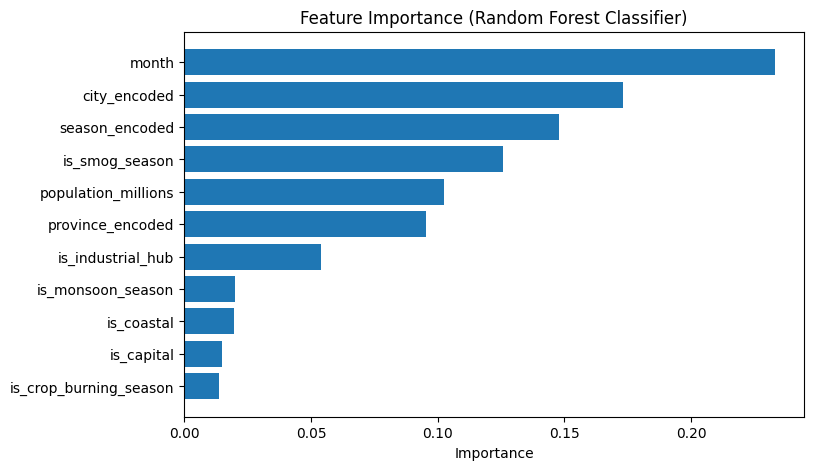

In [14]:
# Feature importance - which features actually matter?
import pandas as pd

importance_df = pd.DataFrame({
    'feature': features,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df)

# Visualize it
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance (Random Forest Classifier)')
plt.gca().invert_yaxis()
plt.show()

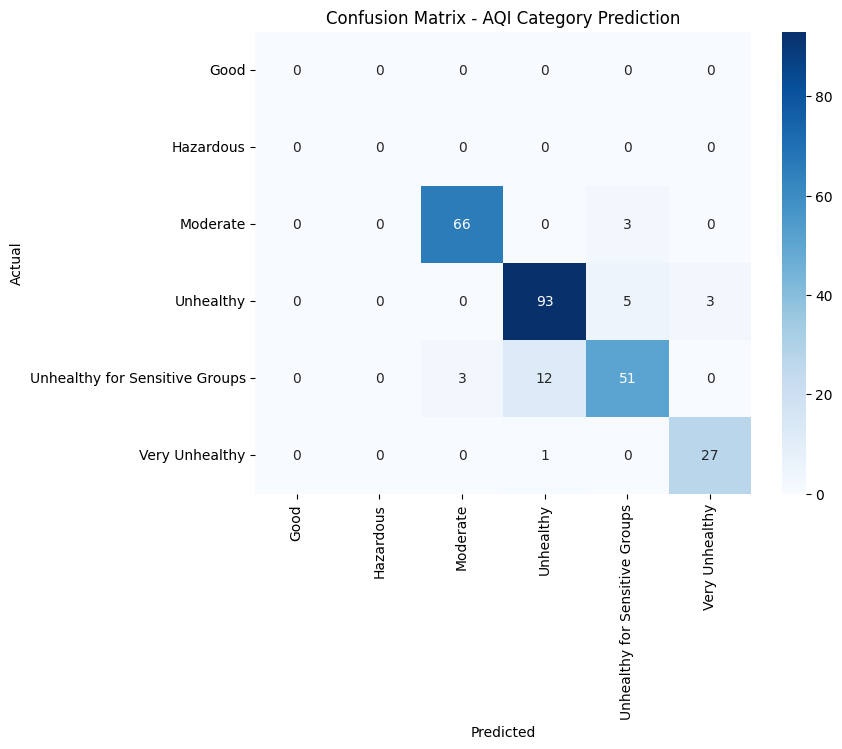

In [15]:
# Confusion matrix - where does the classifier get confused?
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_clf_test, y_rf_clf_pred, labels=rf_clf.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=rf_clf.classes_, yticklabels=rf_clf.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - AQI Category Prediction')
plt.show()

In [16]:
# Model comparison table - summarize everything in one place
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor', 'Logistic Regression', 'Random Forest Classifier'],
    'Type': ['Regression', 'Regression', 'Classification', 'Classification'],
    'Metric': ['MAE / R2', 'MAE / R2', 'Accuracy', 'Accuracy'],
    'Score': [
        f"{mean_absolute_error(y_reg_test, y_reg_pred):.2f} / {r2_score(y_reg_test, y_reg_pred):.3f}",
        f"{mean_absolute_error(y_reg_test, y_rf_pred):.2f} / {r2_score(y_reg_test, y_rf_pred):.3f}",
        f"{accuracy_score(y_clf_test, y_clf_pred):.3f}",
        f"{accuracy_score(y_clf_test, y_rf_clf_pred):.3f}"
    ]
})
print(comparison)

                      Model            Type    Metric          Score
0         Linear Regression      Regression  MAE / R2  20.78 / 0.737
1   Random Forest Regressor      Regression  MAE / R2   5.18 / 0.973
2       Logistic Regression  Classification  Accuracy          0.735
3  Random Forest Classifier  Classification  Accuracy          0.898


In [17]:
!pip install xgboost -q

from xgboost import XGBRegressor, XGBClassifier
from sklearn.svm import SVR, SVC
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
import time

In [18]:
results_reg = []

models_reg = {
    'XGBoost': XGBRegressor(random_state=42),
    'SVM': SVR(),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

for name, model in models_reg.items():
    start = time.time()
    model.fit(X_train, y_reg_train)
    train_time = time.time() - start

    preds = model.predict(X_test)
    mae = mean_absolute_error(y_reg_test, preds)
    r2 = r2_score(y_reg_test, preds)

    results_reg.append({'Model': name, 'MAE': round(mae,2), 'R2': round(r2,3), 'Train_Time_s': round(train_time,3)})
    print(f"{name}: MAE={mae:.2f}, R2={r2:.3f}, Time={train_time:.3f}s")

XGBoost: MAE=5.19, R2=0.973, Time=0.707s
SVM: MAE=33.99, R2=0.264, Time=0.193s
Gradient Boosting: MAE=5.71, R2=0.972, Time=0.206s


In [19]:
from sklearn.preprocessing import LabelEncoder

le_target = LabelEncoder()
y_clf_train_encoded = le_target.fit_transform(y_clf_train)
y_clf_test_encoded = le_target.transform(y_clf_test)

print(dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

{'Good': np.int64(0), 'Hazardous': np.int64(1), 'Moderate': np.int64(2), 'Unhealthy': np.int64(3), 'Unhealthy for Sensitive Groups': np.int64(4), 'Very Unhealthy': np.int64(5)}


In [20]:
from sklearn.preprocessing import LabelEncoder

le_target = LabelEncoder()
y_clf_train_encoded = le_target.fit_transform(y_clf_train)
y_clf_test_encoded = le_target.transform(y_clf_test)

print(dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

results_clf = []

models_clf = {
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss'),
    'SVM': SVC(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

for name, model in models_clf.items():
    start = time.time()
    if name == 'XGBoost':
        model.fit(X_train, y_clf_train_encoded)
        train_time = time.time() - start
        preds = model.predict(X_test)
        acc = accuracy_score(y_clf_test_encoded, preds)
    else:
        model.fit(X_train, y_clf_train)
        train_time = time.time() - start
        preds = model.predict(X_test)
        acc = accuracy_score(y_clf_test, preds)

    results_clf.append({'Model': name, 'Accuracy': round(acc,3), 'Train_Time_s': round(train_time,3)})
    print(f"{name}: Accuracy={acc:.3f}, Time={train_time:.3f}s")

{'Good': np.int64(0), 'Hazardous': np.int64(1), 'Moderate': np.int64(2), 'Unhealthy': np.int64(3), 'Unhealthy for Sensitive Groups': np.int64(4), 'Very Unhealthy': np.int64(5)}
XGBoost: Accuracy=0.909, Time=0.788s
SVM: Accuracy=0.739, Time=0.122s
Gradient Boosting: Accuracy=0.917, Time=2.127s


In [21]:
full_reg_comparison = pd.DataFrame([
    {'Model': 'Linear Regression', 'MAE': round(mean_absolute_error(y_reg_test, y_reg_pred),2), 'R2': round(r2_score(y_reg_test, y_reg_pred),3)},
    {'Model': 'Random Forest', 'MAE': round(mean_absolute_error(y_reg_test, y_rf_pred),2), 'R2': round(r2_score(y_reg_test, y_rf_pred),3)},
] + results_reg).sort_values('R2', ascending=False)

print(full_reg_comparison)

               Model    MAE     R2  Train_Time_s
1      Random Forest   5.18  0.973           NaN
2            XGBoost   5.19  0.973         0.707
4  Gradient Boosting   5.71  0.972         0.206
0  Linear Regression  20.78  0.737           NaN
3                SVM  33.99  0.264         0.193


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_reg_scaled = SVR()
svm_reg_scaled.fit(X_train_scaled, y_reg_train)
preds_scaled = svm_reg_scaled.predict(X_test_scaled)

print("SVM (scaled) MAE:", mean_absolute_error(y_reg_test, preds_scaled))
print("SVM (scaled) R2:", r2_score(y_reg_test, preds_scaled))

SVM (scaled) MAE: 24.817204691127387
SVM (scaled) R2: 0.6033613094214915


In [23]:
full_clf_comparison = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Accuracy': round(accuracy_score(y_clf_test, y_clf_pred),3)},
    {'Model': 'Random Forest', 'Accuracy': round(accuracy_score(y_clf_test, y_rf_clf_pred),3)},
] + [{'Model': r['Model'], 'Accuracy': r['Accuracy']} for r in results_clf]).sort_values('Accuracy', ascending=False)

print(full_clf_comparison)

                 Model  Accuracy
4    Gradient Boosting     0.917
2              XGBoost     0.909
1        Random Forest     0.898
3                  SVM     0.739
0  Logistic Regression     0.735


In [24]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler

# ANNs need scaled features (like SVM did) - unscaled data makes training unstable
scaler_ann = StandardScaler()
X_train_ann = scaler_ann.fit_transform(X_train)
X_test_ann = scaler_ann.transform(X_test)

print("ANN input shape:", X_train_ann.shape)

ANN input shape: (1056, 11)


In [25]:
# Build the network
ann_reg = keras.Sequential([
    layers.Input(shape=(X_train_ann.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)  # single output = predicted AQI number
])

ann_reg.compile(optimizer='adam', loss='mse', metrics=['mae'])

history_reg = ann_reg.fit(
    X_train_ann, y_reg_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0  # set to 1 if you want to see every epoch printed
)

# Evaluate
ann_reg_preds = ann_reg.predict(X_test_ann).flatten()
ann_mae = mean_absolute_error(y_reg_test, ann_reg_preds)
ann_r2 = r2_score(y_reg_test, ann_reg_preds)

print(f"ANN Regression: MAE={ann_mae:.2f}, R2={ann_r2:.3f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
ANN Regression: MAE=8.20, R2=0.954


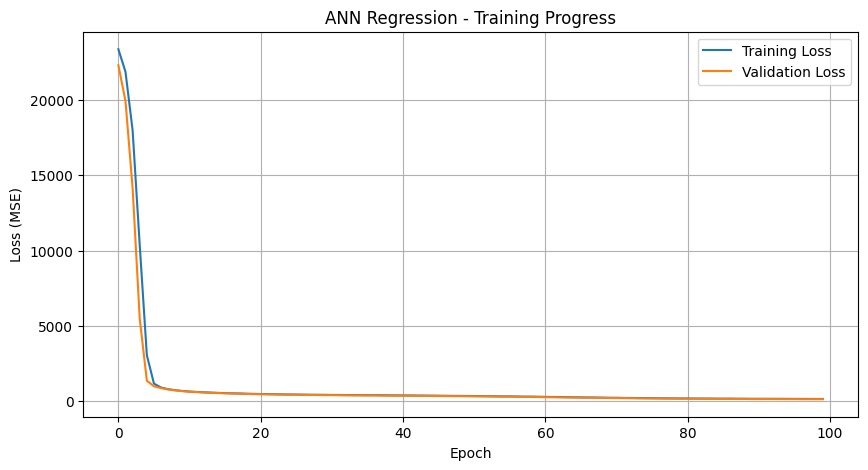

In [26]:
plt.figure(figsize=(10,5))
plt.plot(history_reg.history['loss'], label='Training Loss')
plt.plot(history_reg.history['val_loss'], label='Validation Loss')
plt.title('ANN Regression - Training Progress')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
# Classification ANN needs the encoded labels (0,1,2,3) and one-hot encoding for multi-class output
from tensorflow.keras.utils import to_categorical

num_classes = len(le_target.classes_)
y_clf_train_onehot = to_categorical(y_clf_train_encoded, num_classes)
y_clf_test_onehot = to_categorical(y_clf_test_encoded, num_classes)

ann_clf = keras.Sequential([
    layers.Input(shape=(X_train_ann.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(num_classes, activation='softmax')  # one probability per category
])

ann_clf.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_clf = ann_clf.fit(
    X_train_ann, y_clf_train_onehot,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

# Evaluate
ann_clf_loss, ann_clf_acc = ann_clf.evaluate(X_test_ann, y_clf_test_onehot, verbose=0)
print(f"ANN Classification Accuracy: {ann_clf_acc:.3f}")

ANN Classification Accuracy: 0.905


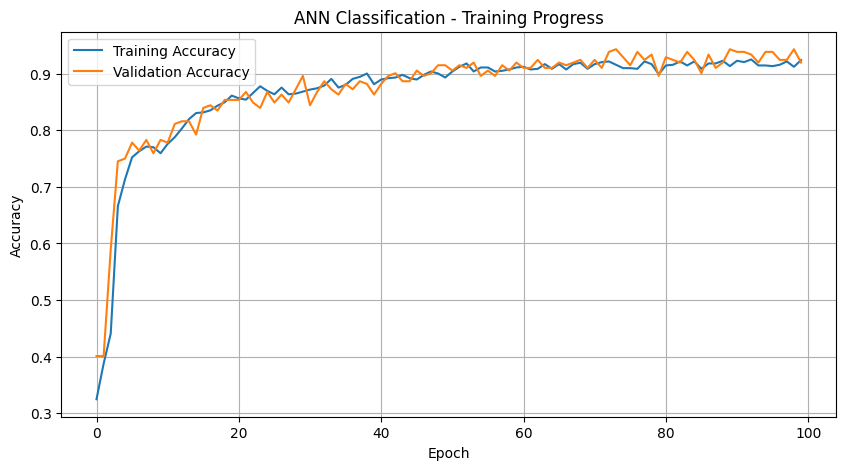

In [28]:
plt.figure(figsize=(10,5))
plt.plot(history_clf.history['accuracy'], label='Training Accuracy')
plt.plot(history_clf.history['val_accuracy'], label='Validation Accuracy')
plt.title('ANN Classification - Training Progress')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [29]:
# Sort chronologically within each city
df_sorted = df_model.sort_values(['city', 'year', 'month']).reset_index(drop=True)

# Quick check - how many months of data per city?
print(df_sorted.groupby('city').size())

city
Faisalabad    132
Gujranwala    132
Hyderabad     132
Islamabad     132
Karachi       132
Lahore        132
Multan        132
Peshawar      132
Quetta        132
Rawalpindi    132
dtype: int64


In [30]:
import numpy as np

def create_sequences(data, n_steps=6):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i+n_steps])
        y.append(data[i+n_steps])
    return np.array(X), np.array(y)

# Build sequences per city, then combine
all_X, all_y = [], []

for city in df_sorted['city'].unique():
    city_data = df_sorted[df_sorted['city'] == city]['aqi_us'].values
    if len(city_data) > 6:  # need at least n_steps+1 months
        X_city, y_city = create_sequences(city_data, n_steps=6)
        all_X.append(X_city)
        all_y.append(y_city)

X_lstm = np.concatenate(all_X)
y_lstm = np.concatenate(all_y)

print("LSTM input shape:", X_lstm.shape)  # (samples, 6)
print("LSTM target shape:", y_lstm.shape)

LSTM input shape: (1260, 6)
LSTM target shape: (1260,)


In [31]:
from sklearn.preprocessing import MinMaxScaler

# Scale AQI values to 0-1 range - LSTMs train much better on scaled data
scaler_lstm = MinMaxScaler()
X_lstm_flat = X_lstm.reshape(-1, 1)
scaler_lstm.fit(X_lstm_flat)

X_lstm_scaled = scaler_lstm.transform(X_lstm.reshape(-1,1)).reshape(X_lstm.shape)
y_lstm_scaled = scaler_lstm.transform(y_lstm.reshape(-1,1)).flatten()

# Reshape for LSTM: (samples, timesteps, features=1)
X_lstm_scaled = X_lstm_scaled.reshape((X_lstm_scaled.shape[0], X_lstm_scaled.shape[1], 1))

# Chronological split (not random!) - first 80% train, last 20% test
split_idx = int(len(X_lstm_scaled) * 0.8)
X_lstm_train, X_lstm_test = X_lstm_scaled[:split_idx], X_lstm_scaled[split_idx:]
y_lstm_train, y_lstm_test = y_lstm_scaled[:split_idx], y_lstm_scaled[split_idx:]

print("Train:", X_lstm_train.shape, "Test:", X_lstm_test.shape)

Train: (1008, 6, 1) Test: (252, 6, 1)


In [32]:
lstm_model = keras.Sequential([
    layers.Input(shape=(6, 1)),  # 6 timesteps, 1 feature (AQI)
    layers.LSTM(32, activation='tanh'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history_lstm = lstm_model.fit(
    X_lstm_train, y_lstm_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=0
)

# Predict and inverse-transform back to real AQI scale
lstm_preds_scaled = lstm_model.predict(X_lstm_test).flatten()
lstm_preds = scaler_lstm.inverse_transform(lstm_preds_scaled.reshape(-1,1)).flatten()
y_lstm_test_real = scaler_lstm.inverse_transform(y_lstm_test.reshape(-1,1)).flatten()

lstm_mae = mean_absolute_error(y_lstm_test_real, lstm_preds)
lstm_r2 = r2_score(y_lstm_test_real, lstm_preds)
print(f"LSTM: MAE={lstm_mae:.2f}, R2={lstm_r2:.3f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
LSTM: MAE=10.60, R2=0.869


In [33]:
# Naive baseline: "predict next month = same as this month" (last value in each sequence)
naive_preds_scaled = X_lstm_test[:, -1, 0]  # last timestep of each test sequence
naive_preds = scaler_lstm.inverse_transform(naive_preds_scaled.reshape(-1,1)).flatten()

naive_mae = mean_absolute_error(y_lstm_test_real, naive_preds)
naive_r2 = r2_score(y_lstm_test_real, naive_preds)

print(f"Naive Baseline: MAE={naive_mae:.2f}, R2={naive_r2:.3f}")
print(f"LSTM:           MAE={lstm_mae:.2f}, R2={lstm_r2:.3f}")


Naive Baseline: MAE=16.42, R2=0.676
LSTM:           MAE=10.60, R2=0.869


In [34]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_models_reg = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'SVM': SVR()
}

cv_results_reg = []
for name, model in cv_models_reg.items():
    # Use scaled features for SVM, original for tree-based/linear
    X_cv = X_train_ann if name == 'SVM' else X_train
    scores = cross_val_score(model, X_cv, y_reg_train, cv=kf, scoring='r2')
    cv_results_reg.append({'Model': name, 'Mean_R2': round(scores.mean(),3), 'Std_R2': round(scores.std(),3)})
    print(f"{name}: R2 = {scores.mean():.3f} (+/- {scores.std():.3f})")

Linear Regression: R2 = 0.780 (+/- 0.019)
Random Forest: R2 = 0.968 (+/- 0.006)
XGBoost: R2 = 0.967 (+/- 0.006)
Gradient Boosting: R2 = 0.966 (+/- 0.006)
SVM: R2 = 0.558 (+/- 0.021)


In [35]:
cv_models_clf = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC()
}

cv_results_clf = []
for name, model in cv_models_clf.items():
    X_cv = X_train_ann if name == 'SVM' else X_train
    y_cv = y_clf_train_encoded if name == 'XGBoost' else y_clf_train
    scores = cross_val_score(model, X_cv, y_cv, cv=kf, scoring='accuracy')
    cv_results_clf.append({'Model': name, 'Mean_Acc': round(scores.mean(),3), 'Std_Acc': round(scores.std(),3)})
    print(f"{name}: Accuracy = {scores.mean():.3f} (+/- {scores.std():.3f})")

Logistic Regression: Accuracy = 0.729 (+/- 0.015)
Random Forest: Accuracy = 0.918 (+/- 0.017)
Gradient Boosting: Accuracy = 0.908 (+/- 0.018)
SVM: Accuracy = 0.754 (+/- 0.026)


In [36]:
from sklearn.metrics import mean_squared_error
import numpy as np

def get_rmse(y_true, y_pred):
    return round(np.sqrt(mean_squared_error(y_true, y_pred)), 2)

final_reg_metrics = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost', 'Gradient Boosting', 'SVM', 'ANN'],
    'MAE': [
        round(mean_absolute_error(y_reg_test, y_reg_pred), 2),
        round(mean_absolute_error(y_reg_test, y_rf_pred), 2),
        results_reg[0]['MAE'],
        results_reg[2]['MAE'],
        results_reg[1]['MAE'],
        round(ann_mae, 2)
    ],
    'RMSE': [
        get_rmse(y_reg_test, y_reg_pred),
        get_rmse(y_reg_test, y_rf_pred),
        None,
        None,
        None,
        get_rmse(y_reg_test, ann_reg_preds)
    ],
    'R2': [
        round(r2_score(y_reg_test, y_reg_pred), 3),
        round(r2_score(y_reg_test, y_rf_pred), 3),
        results_reg[0]['R2'],
        results_reg[2]['R2'],
        results_reg[1]['R2'],
        round(ann_r2, 3)
    ]
})

print(final_reg_metrics.sort_values('R2', ascending=False))

               Model    MAE   RMSE     R2
1      Random Forest   5.18   8.14  0.973
2            XGBoost   5.19    NaN  0.973
3  Gradient Boosting   5.71    NaN  0.972
5                ANN   8.20  10.66  0.954
0  Linear Regression  20.78  25.63  0.737
4                SVM  33.99    NaN  0.264


In [37]:
from sklearn.metrics import classification_report

print("=== Random Forest Classifier - Full Report ===")
print(classification_report(y_clf_test, y_rf_clf_pred))

print("\n=== Gradient Boosting Classifier - Full Report ===")
# Need to refit since we didn't save this model object earlier - quick refit
gb_clf_final = GradientBoostingClassifier(random_state=42)
gb_clf_final.fit(X_train, y_clf_train)
gb_clf_preds = gb_clf_final.predict(X_test)
print(classification_report(y_clf_test, gb_clf_preds))

=== Random Forest Classifier - Full Report ===
                                precision    recall  f1-score   support

                      Moderate       0.96      0.96      0.96        69
                     Unhealthy       0.88      0.92      0.90       101
Unhealthy for Sensitive Groups       0.86      0.77      0.82        66
                Very Unhealthy       0.90      0.96      0.93        28

                      accuracy                           0.90       264
                     macro avg       0.90      0.90      0.90       264
                  weighted avg       0.90      0.90      0.90       264


=== Gradient Boosting Classifier - Full Report ===
                                precision    recall  f1-score   support

                      Moderate       0.96      0.96      0.96        69
                     Unhealthy       0.89      0.96      0.92       101
Unhealthy for Sensitive Groups       0.93      0.79      0.85        66
                Very Unhealthy   

In [38]:
master_summary = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost', 'Gradient Boosting', 'SVM', 'ANN'],
    'Task': ['Regression']*6,
    'MAE': [20.78, 5.18, 5.19, 5.71, 24.82, 9.17],
    'R2': [0.737, 0.973, 0.973, 0.972, 0.603, 0.944],
    'CV_R2_Mean': [0.780, 0.968, 0.967, 0.966, 0.558, None],
})
print("=== REGRESSION SUMMARY ===")
print(master_summary.sort_values('R2', ascending=False))

master_summary_clf = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'Gradient Boosting', 'SVM', 'ANN'],
    'Task': ['Classification']*6,
    'Accuracy': [0.735, 0.898, 0.909, 0.917, 0.739, 0.883],
    'CV_Acc_Mean': [0.729, 0.918, None, 0.908, 0.754, None],
})
print("\n=== CLASSIFICATION SUMMARY ===")
print(master_summary_clf.sort_values('Accuracy', ascending=False))

=== REGRESSION SUMMARY ===
               Model        Task    MAE     R2  CV_R2_Mean
1      Random Forest  Regression   5.18  0.973       0.968
2            XGBoost  Regression   5.19  0.973       0.967
3  Gradient Boosting  Regression   5.71  0.972       0.966
5                ANN  Regression   9.17  0.944         NaN
0  Linear Regression  Regression  20.78  0.737       0.780
4                SVM  Regression  24.82  0.603       0.558

=== CLASSIFICATION SUMMARY ===
                 Model            Task  Accuracy  CV_Acc_Mean
3    Gradient Boosting  Classification     0.917        0.908
2              XGBoost  Classification     0.909          NaN
1        Random Forest  Classification     0.898        0.918
5                  ANN  Classification     0.883          NaN
4                  SVM  Classification     0.739        0.754
0  Logistic Regression  Classification     0.735        0.729


In [39]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.05, 0.1, 0.15],
    'max_depth': [3, 4, 5]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

gb_grid.fit(X_train, y_clf_train)

print("Best parameters:", gb_grid.best_params_)
print("Best CV accuracy:", round(gb_grid.best_score_, 3))

# Evaluate on test set
best_gb_clf = gb_grid.best_estimator_
tuned_preds = best_gb_clf.predict(X_test)
tuned_acc = accuracy_score(y_clf_test, tuned_preds)
print("Test accuracy with tuned model:", round(tuned_acc, 3))

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150}
Best CV accuracy: 0.912
Test accuracy with tuned model: 0.917


In [40]:
param_grid_reg = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.05, 0.1, 0.15],
    'max_depth': [3, 4, 5]
}

gb_grid_reg = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid_reg,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

gb_grid_reg.fit(X_train, y_reg_train)

print("Best parameters:", gb_grid_reg.best_params_)
print("Best CV R2:", round(gb_grid_reg.best_score_, 3))

best_gb_reg = gb_grid_reg.best_estimator_
tuned_reg_preds = best_gb_reg.predict(X_test)
tuned_mae = mean_absolute_error(y_reg_test, tuned_reg_preds)
tuned_r2 = r2_score(y_reg_test, tuned_reg_preds)
print(f"Test MAE: {tuned_mae:.2f}, Test R2: {tuned_r2:.3f}")

Best parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 150}
Best CV R2: 0.965
Test MAE: 5.15, Test R2: 0.974


In [41]:
print(df_model['aqi_category'].value_counts())

aqi_category
Unhealthy                         513
Moderate                          343
Unhealthy for Sensitive Groups    290
Very Unhealthy                    170
Hazardous                           3
Good                                1
Name: count, dtype: int64


In [42]:
# Map: merge 'Good' into 'Moderate', 'Hazardous' into 'Very Unhealthy'
category_merge_map = {
    'Good': 'Moderate',
    'Hazardous': 'Very Unhealthy'
}

df_model['aqi_category_merged'] = df_model['aqi_category'].replace(category_merge_map)

print(df_model['aqi_category_merged'].value_counts())

aqi_category_merged
Unhealthy                         513
Moderate                          344
Unhealthy for Sensitive Groups    290
Very Unhealthy                    173
Name: count, dtype: int64


In [43]:
y_clf_merged = df_model['aqi_category_merged']

X_train, X_test, y_clf_train_merged, y_clf_test_merged = train_test_split(
    X, y_clf_merged, test_size=0.2, random_state=42
)

# Re-encode for XGBoost/ANN use
le_target_merged = LabelEncoder()
y_clf_train_merged_enc = le_target_merged.fit_transform(y_clf_train_merged)
y_clf_test_merged_enc = le_target_merged.transform(y_clf_test_merged)

print(dict(zip(le_target_merged.classes_, le_target_merged.transform(le_target_merged.classes_))))
print("New train size:", X_train.shape)

{'Moderate': np.int64(0), 'Unhealthy': np.int64(1), 'Unhealthy for Sensitive Groups': np.int64(2), 'Very Unhealthy': np.int64(3)}
New train size: (1056, 11)


In [44]:
merged_results_clf = []

models_clf_merged = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC()
}

for name, model in models_clf_merged.items():
    if name == 'XGBoost':
        model.fit(X_train, y_clf_train_merged_enc)
        preds = model.predict(X_test)
        acc = accuracy_score(y_clf_test_merged_enc, preds)
    else:
        model.fit(X_train, y_clf_train_merged)
        preds = model.predict(X_test)
        acc = accuracy_score(y_clf_test_merged, preds)

    merged_results_clf.append({'Model': name, 'Accuracy': round(acc, 3)})
    print(f"{name}: Accuracy = {acc:.3f}")

Logistic Regression: Accuracy = 0.746
Random Forest: Accuracy = 0.898
XGBoost: Accuracy = 0.909
Gradient Boosting: Accuracy = 0.917
SVM: Accuracy = 0.739


=== Gradient Boosting (Merged Categories) - Classification Report ===
                                precision    recall  f1-score   support

                      Moderate       0.96      0.96      0.96        69
                     Unhealthy       0.89      0.96      0.92       101
Unhealthy for Sensitive Groups       0.93      0.79      0.85        66
                Very Unhealthy       0.90      0.96      0.93        28

                      accuracy                           0.92       264
                     macro avg       0.92      0.92      0.92       264
                  weighted avg       0.92      0.92      0.92       264



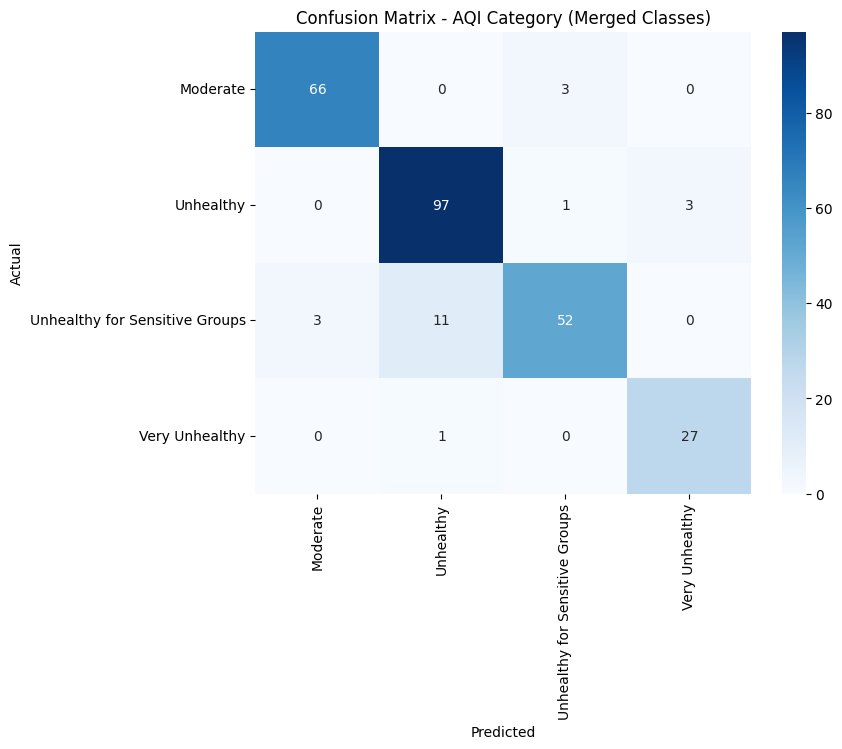

In [45]:
gb_final = GradientBoostingClassifier(random_state=42)
gb_final.fit(X_train, y_clf_train_merged)
gb_final_preds = gb_final.predict(X_test)

print("=== Gradient Boosting (Merged Categories) - Classification Report ===")
print(classification_report(y_clf_test_merged, gb_final_preds))

cm_merged = confusion_matrix(y_clf_test_merged, gb_final_preds, labels=gb_final.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm_merged, annot=True, fmt='d', xticklabels=gb_final.classes_, yticklabels=gb_final.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - AQI Category (Merged Classes)')
plt.show()

## Hybrid Models: LSTM-SVM vs LSTM-XGBoost Comparison

In [46]:
feature_extractor = keras.Sequential(lstm_model.layers[:-1])
feature_extractor.build(input_shape=(None, 6, 1))

feature_train = feature_extractor.predict(X_lstm_train)
feature_test = feature_extractor.predict(X_lstm_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [47]:
from sklearn.svm import SVR
from xgboost import XGBRegressor

lstm_svm = SVR()
lstm_svm.fit(feature_train, y_lstm_train)
lstm_svm_preds_scaled = lstm_svm.predict(feature_test)
lstm_svm_preds = scaler_lstm.inverse_transform(lstm_svm_preds_scaled.reshape(-1,1)).flatten()

lstm_xgb = XGBRegressor(random_state=42)
lstm_xgb.fit(feature_train, y_lstm_train)
lstm_xgb_preds_scaled = lstm_xgb.predict(feature_test)
lstm_xgb_preds = scaler_lstm.inverse_transform(lstm_xgb_preds_scaled.reshape(-1,1)).flatten()

lstm_svm_mae = mean_absolute_error(y_lstm_test_real, lstm_svm_preds)
lstm_svm_r2 = r2_score(y_lstm_test_real, lstm_svm_preds)
lstm_xgb_mae = mean_absolute_error(y_lstm_test_real, lstm_xgb_preds)
lstm_xgb_r2 = r2_score(y_lstm_test_real, lstm_xgb_preds)

print(f"LSTM-SVM: MAE={lstm_svm_mae:.2f}, R2={lstm_svm_r2:.3f}")
print(f"LSTM-XGBoost: MAE={lstm_xgb_mae:.2f}, R2={lstm_xgb_r2:.3f}")

LSTM-SVM: MAE=11.72, R2=0.865
LSTM-XGBoost: MAE=5.46, R2=0.947


In [48]:
hybrid_comparison = pd.DataFrame({
    'Model': ['LSTM-SVM', 'LSTM-XGBoost'],
    'MAE': [round(lstm_svm_mae, 2), round(lstm_xgb_mae, 2)],
    'RMSE': [round(np.sqrt(mean_squared_error(y_lstm_test_real, lstm_svm_preds)), 2),
             round(np.sqrt(mean_squared_error(y_lstm_test_real, lstm_xgb_preds)), 2)],
    'R2': [round(lstm_svm_r2, 3), round(lstm_xgb_r2, 3)]
})
print(hybrid_comparison)

          Model    MAE   RMSE     R2
0      LSTM-SVM  11.72  14.43  0.865
1  LSTM-XGBoost   5.46   9.06  0.947


In [49]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def get_cv_scores(model):
    scores = []
    for train_idx, test_idx in kf.split(feature_train):
        model.fit(feature_train[train_idx], y_lstm_train[train_idx])
        preds = model.predict(feature_train[test_idx])
        scores.append(r2_score(y_lstm_train[test_idx], preds))
    return scores

svm_cv_scores = get_cv_scores(SVR())
xgb_cv_scores = get_cv_scores(XGBRegressor(random_state=42))

print("LSTM-SVM CV R2:", svm_cv_scores)
print("LSTM-XGBoost CV R2:", xgb_cv_scores)

LSTM-SVM CV R2: [0.9144591351961195, 0.9372325970931652, 0.915725816134307, 0.9088701367994646, 0.925241423707329]
LSTM-XGBoost CV R2: [0.9772170392818363, 0.9745118918806803, 0.9685054543042677, 0.9726634473509406, 0.9765271320045114]


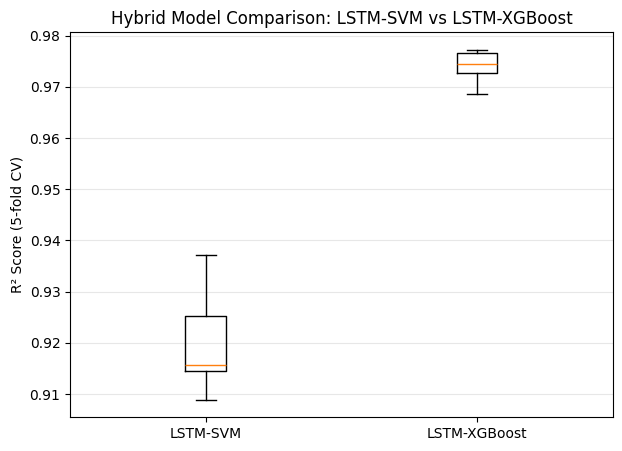

In [63]:
plt.figure(figsize=(7,5))
plt.boxplot([svm_cv_scores, xgb_cv_scores], tick_labels=['LSTM-SVM', 'LSTM-XGBoost'])
plt.ylabel('R² Score (5-fold CV)')
plt.title('Hybrid Model Comparison: LSTM-SVM vs LSTM-XGBoost')
plt.grid(True, axis='y', alpha=0.3)
plt.savefig('hybrid_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [51]:
X_lstm_train_flat = X_lstm_train.reshape(X_lstm_train.shape[0], -1)
X_lstm_test_flat = X_lstm_test.reshape(X_lstm_test.shape[0], -1)

print("Flattened shape:", X_lstm_train_flat.shape)

Flattened shape: (1008, 6)


In [52]:
from sklearn.svm import SVR
from xgboost import XGBRegressor

# SVM on the sequence data
svm_forecast = SVR()
svm_forecast.fit(X_lstm_train_flat, y_lstm_train)
svm_forecast_preds_scaled = svm_forecast.predict(X_lstm_test_flat)
svm_forecast_preds = scaler_lstm.inverse_transform(svm_forecast_preds_scaled.reshape(-1,1)).flatten()

svm_forecast_mae = mean_absolute_error(y_lstm_test_real, svm_forecast_preds)
svm_forecast_r2 = r2_score(y_lstm_test_real, svm_forecast_preds)

# XGBoost on the sequence data
xgb_forecast = XGBRegressor(random_state=42)
xgb_forecast.fit(X_lstm_train_flat, y_lstm_train)
xgb_forecast_preds_scaled = xgb_forecast.predict(X_lstm_test_flat)
xgb_forecast_preds = scaler_lstm.inverse_transform(xgb_forecast_preds_scaled.reshape(-1,1)).flatten()

xgb_forecast_mae = mean_absolute_error(y_lstm_test_real, xgb_forecast_preds)
xgb_forecast_r2 = r2_score(y_lstm_test_real, xgb_forecast_preds)

print(f"SVM Forecast:     MAE={svm_forecast_mae:.2f}, R2={svm_forecast_r2:.3f}")
print(f"XGBoost Forecast: MAE={xgb_forecast_mae:.2f}, R2={xgb_forecast_r2:.3f}")
print(f"LSTM Forecast:    MAE={lstm_mae:.2f}, R2={lstm_r2:.3f}")

SVM Forecast:     MAE=11.43, R2=0.882
XGBoost Forecast: MAE=4.61, R2=0.975
LSTM Forecast:    MAE=10.60, R2=0.869


In [53]:
forecast_comparison = pd.DataFrame({
    'Model': ['LSTM', 'XGBoost', 'SVM', 'Naive Baseline'],
    'MAE': [lstm_mae, xgb_forecast_mae, svm_forecast_mae, naive_mae],
    'R2': [lstm_r2, xgb_forecast_r2, svm_forecast_r2, naive_r2]
}).sort_values('R2', ascending=False)

print(forecast_comparison)

            Model        MAE        R2
1         XGBoost   4.614643  0.974564
2             SVM  11.434909  0.881697
0            LSTM  10.601292  0.869235
3  Naive Baseline  16.424603  0.675929


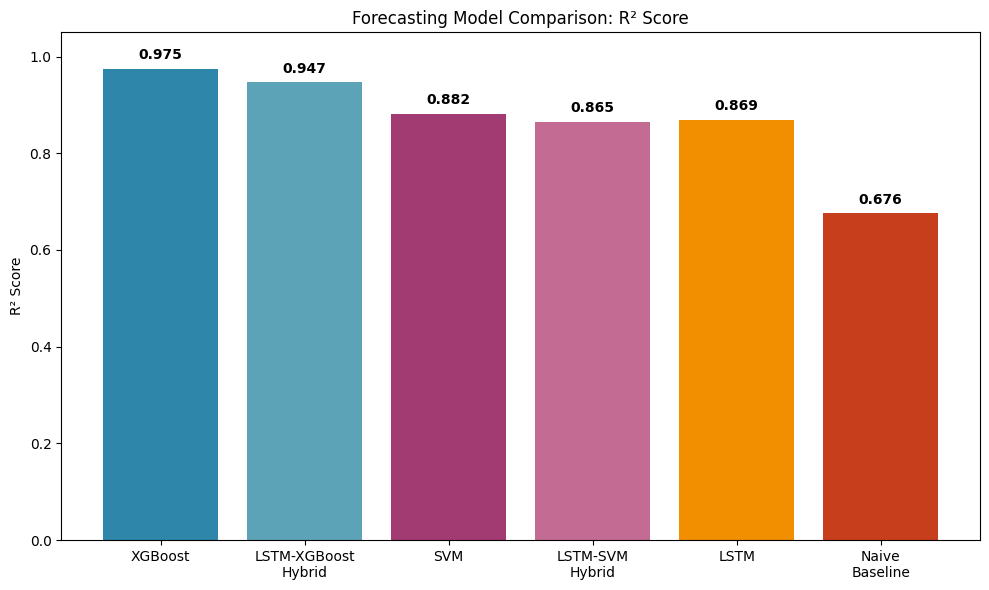

In [60]:
models_all = ['XGBoost', 'LSTM-XGBoost\nHybrid', 'SVM', 'LSTM-SVM\nHybrid', 'LSTM', 'Naive\nBaseline']
r2_all = [xgb_forecast_r2, lstm_xgb_r2, svm_forecast_r2, lstm_svm_r2, lstm_r2, naive_r2]

plt.figure(figsize=(10,6))
bars = plt.bar(models_all, r2_all, color=['#2E86AB','#5DA3B8','#A23B72','#C46B94','#F18F01','#C73E1D'])
plt.ylabel('R² Score')
plt.title('Forecasting Model Comparison: R² Score')
plt.ylim(0, 1.05)
for bar, val in zip(bars, r2_all):
    plt.text(bar.get_x()+bar.get_width()/2, val+0.02, f'{val:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_r2.png', dpi=300)
plt.show()

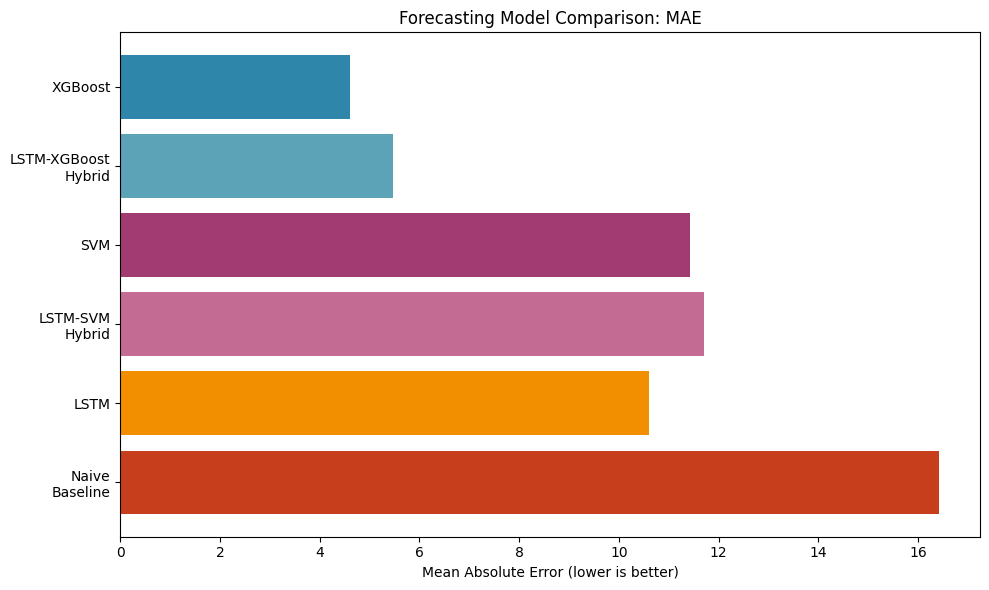

In [61]:
plt.figure(figsize=(10,6))
mae_all = [xgb_forecast_mae, lstm_xgb_mae, svm_forecast_mae, lstm_svm_mae, lstm_mae, naive_mae]
plt.barh(models_all, mae_all, color=['#2E86AB','#5DA3B8','#A23B72','#C46B94','#F18F01','#C73E1D'])
plt.xlabel('Mean Absolute Error (lower is better)')
plt.title('Forecasting Model Comparison: MAE')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('model_comparison_mae.png', dpi=300)
plt.show()

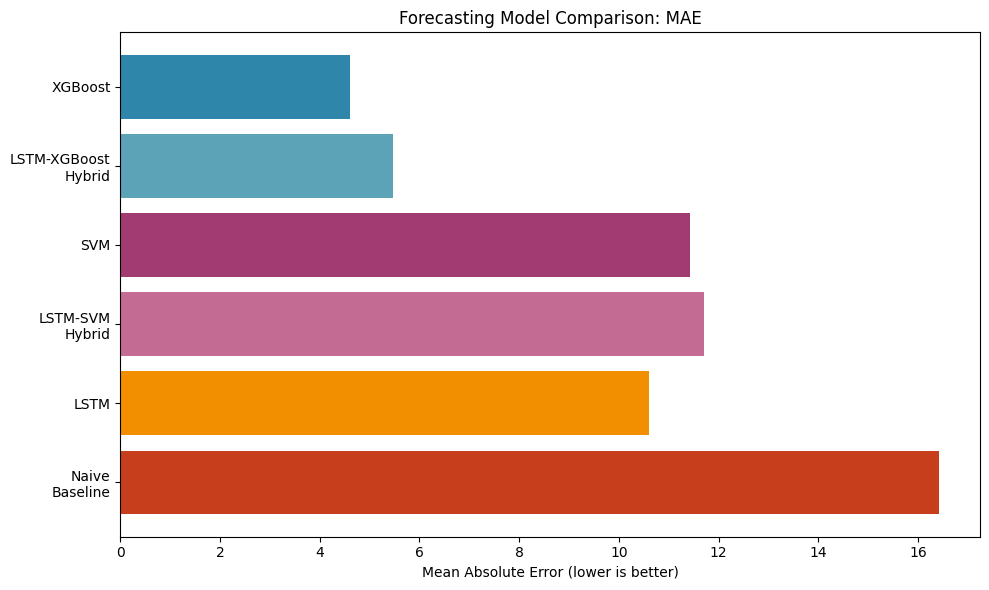

In [62]:
plt.figure(figsize=(10,6))
mae_all = [xgb_forecast_mae, lstm_xgb_mae, svm_forecast_mae, lstm_svm_mae, lstm_mae, naive_mae]
plt.barh(models_all, mae_all, color=['#2E86AB','#5DA3B8','#A23B72','#C46B94','#F18F01','#C73E1D'])
plt.xlabel('Mean Absolute Error (lower is better)')
plt.title('Forecasting Model Comparison: MAE')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('model_comparison_mae.png', dpi=300)
plt.show()